# Who is hit hardest by Inflation?
**Team Name:** Inflators
- Sanjana Devakumaran *(sanjud)*
- Sanjna Rachakonda *(sanjnarachakonda)*
- Tommy Ayers *(tlayers21)*
- Johnson Hwang *(hjohnson22)*
## Project Introduction
This project will investigate which groups are hit the hardest by inflation in the United States. We will evaluate and compare inflation trends with wage changes across 5 income levels (quintiles) to understand how inflation affects different parts of the population. To this end, we plan on comparing CPI (consumer price index) and mean household income to discover if there has been a decline in purchasing power which in turn, leads to higher cost-of-living pressures. We will be analyzing datasets that contain data from 2005 to 2022.
## Research Questions
1. Does inflation affect low-income groups more severely than high-income ones?
2. Do wages keep up with inflation across different industries?
3. Are certain states hit harder by inflation than others?
## Potential Data Sources
- Atlanta FED - Wage Growth: https://www.atlantafed.org/research-and-data/data/wage-growth-tracker
- FRED - Historical Wages With and Without Inflation: https://fred.stlouisfed.org/tags/series?t=inflation;wages
- BEA – Regional Price Parities: https://www.bea.gov/data/prices-inflation/regional-price-parities-state-and-metro-area
- BLS - Real Earnings: https://www.bls.gov/news.release/realer.htm


# Data
- R-CPI-I: CPI amongst different household income quintiles (https://www.bls.gov/cpi/research-series/r-cpi-i.htm)
- Mean Household Income by Quintile (https://taxpolicycenter.org/statistics/household-income-quintiles)

### Loading CPI Data (Income Quintile)

We begin by loading the R-CPI-I dataset, which measures Consumer Price Index (CPI) across different household income quintiles. CPI measures the average change over time in the prices paid by urban consumers for a market basket of consumer goods. Thus, this dataset allows us to compare how inflation changes over time for different income groups. We are intentionally skipping the first row because it contains context instead of column names. We use the first actual row as the header.

In [1]:
import pandas

r_cpi_i = pandas.read_excel("data/r-cpi-i-data.xlsx", skiprows=1, header=0)
r_cpi_i.head()

,Year,Month,R-CPI-I1,R-CPI-I2,R-CPI-I3,R-CPI-I4,R-CPI-I5
0,2005,12,100.000,100.000,100.000,100.000,100.000
1,2006,1,100.708,100.745,100.756,100.749,100.805
2,2006,2,100.822,100.908,100.933,100.965,101.123
3,2006,3,101.315,101.418,101.454,101.549,101.775
4,2006,4,102.123,102.268,102.290,102.413,102.594


### Loading Mean Income Data by Quintile

To better understand how inflation affects different groups and answer our research question, we also loaded a dataset containing average income values for each income quintile. This data shows that even if inflation rates are similar across groups, lower-income households may be more affected because they have less income to account for rising costs. This dataset will also later allow us to compare inflation trends with income levels. The dataset is loaded directly from an Excel file with standard column headers.

In [2]:
income_quintiles = pandas.read_excel("data/mean_income_quintiles.xlsx", header=0)
income_quintiles

,Year,Income-1,Income-2,Income-3,Income-4,Income-5
0,2005,10660,27360,46300,72830,159580
1,2006,11350,28780,48220,76330,168170
2,2007,11550,29440,49970,79110,167970
3,2008,11660,29520,50130,79760,171060
4,2009,11550,29260,49530,78690,170840
5,2010,10990,28530,49170,78880,169390
6,2011,11240,29200,49840,80080,178020
7,2012,11490,29700,51180,82100,181910
8,2013,11590,30810,53740,86470,193350
9,2014,11680,31090,54040,87830,194050


In order to properly assess the monthly quintile data with the yearly income data, each quintile for each year is averaged so both datasets can be joined.

In [3]:
# 2005 is dropped since it only contained data for December and not all 12 months
yearly_r_cpi_i = r_cpi_i.drop('Month', axis=1).groupby('Year').mean().iloc[1:, :].reset_index()
yearly_r_cpi_i.head()

,Year,R-CPI-I1,R-CPI-I2,R-CPI-I3,R-CPI-I4,R-CPI-I5
0,2006,102.345000,102.394583,102.356667,102.445250,102.614333
1,2007,105.619917,105.436333,105.252917,105.313500,105.335833
2,2008,110.252333,109.873250,109.410750,109.340417,108.907500
3,2009,110.224750,109.472500,108.853917,108.843333,108.549417
4,2010,112.250917,111.551333,110.933667,110.745167,109.964167


### Joining CPI Data with Income Data

In order to better understand how inflation affects different income groups we combined the CPI dataset from earlier with the mean income dataset. We did a merge on the Year column because the CPI data is recorded monthly but the income data is yearly. In addition, matching by year allows us to align inflation values with their corresponding income levels. The join lets us compare inflation (CPI) with income levels, understand if lower income groups are hit harder from inflation, and prepare the data for combined analysis. We used a left join to preserve all CPI observations while adding income information.

In [4]:
joined = pandas.merge(yearly_r_cpi_i, income_quintiles, left_on='Year', right_on='Year')
joined

,Year,R-CPI-I1,R-CPI-I2,R-CPI-I3,R-CPI-I4,R-CPI-I5,Income-1,Income-2,Income-3,Income-4,Income-5
0,2006,102.345000,102.394583,102.356667,102.445250,102.614333,11350,28780,48220,76330,168170
1,2007,105.619917,105.436333,105.252917,105.313500,105.335833,11550,29440,49970,79110,167970
2,2008,110.252333,109.873250,109.410750,109.340417,108.907500,11660,29520,50130,79760,171060
3,2009,110.224750,109.472500,108.853917,108.843333,108.549417,11550,29260,49530,78690,170840
4,2010,112.250917,111.551333,110.933667,110.745167,109.964167,10990,28530,49170,78880,169390
5,2011,115.982750,115.330667,114.691417,114.332500,113.094500,11240,29200,49840,80080,178020
6,2012,118.565750,117.814167,117.121583,116.678833,115.348250,11490,29700,51180,82100,181910
7,2013,120.389250,119.560583,118.853500,118.316333,117.039917,11590,30810,53740,86470,193350
8,2014,122.543417,121.607667,120.796917,120.160833,118.862917,11680,31090,54040,87830,194050
9,2015,122.820083,121.638250,120.643833,120.096917,119.309333,12460,32630,56830,92030,202370


### Reshaping Joined Data

After merging the CPI and income datasets, the data was still in a wide format and each quintile had its own set of columns. In order to make the dataset easier to analyze and visualize we converted it into a long format. Now, each row represents a single observation for a specific quintile, month, and year. Additionally, CPI and income values are stored in joint columns instead of separate columns per quintile. Converting to long format allowed us to more easily group and compare quintiles, create cleaner visualizations, and perform analysis across income groups. 

In [5]:
joined = pandas.merge(yearly_r_cpi_i, income_quintiles, on='Year')

dfs = []

# Concatenate data for each quintile into a long format DataFrame
for quintile in range(1, 6):
    temp = joined[['Year', f'R-CPI-I{quintile}', f'Income-{quintile}']].copy()
    
    temp = temp.rename(columns={f'R-CPI-I{quintile}': 'CPI',
                                f'Income-{quintile}': 'Income'})
    
    temp['Quintile'] = quintile
    dfs.append(temp)

joined_long = pandas.concat(dfs, ignore_index=True)
joined_long = joined_long[['Year', 'Quintile', 'CPI', 'Income']]

joined_long

,Year,Quintile,CPI,Income
0,2006,1,102.345000,11350
1,2007,1,105.619917,11550
2,2008,1,110.252333,11660
3,2009,1,110.224750,11550
4,2010,1,112.250917,10990
...,...,...,...,...
80,2018,5,126.260083,233900
81,2019,5,128.611917,254450
82,2020,5,130.041500,253480
83,2021,5,135.799083,269360


## Real Income Growth

$$\text{Real Income} = \frac{\text{Nominal Income}}{\text{CPI}} \cdot 100$$

In [6]:
joined_long['Real Income'] = joined_long['Income'] / joined_long['CPI'] * 100
joined_long.head()

,Year,Quintile,CPI,Income,Real Income
0,2006,1,102.345000,11350,11089.940886
1,2007,1,105.619917,11550,10935.437524
2,2008,1,110.252333,11660,10575.739894
3,2009,1,110.224750,11550,10478.590335
4,2010,1,112.250917,10990,9790.565927


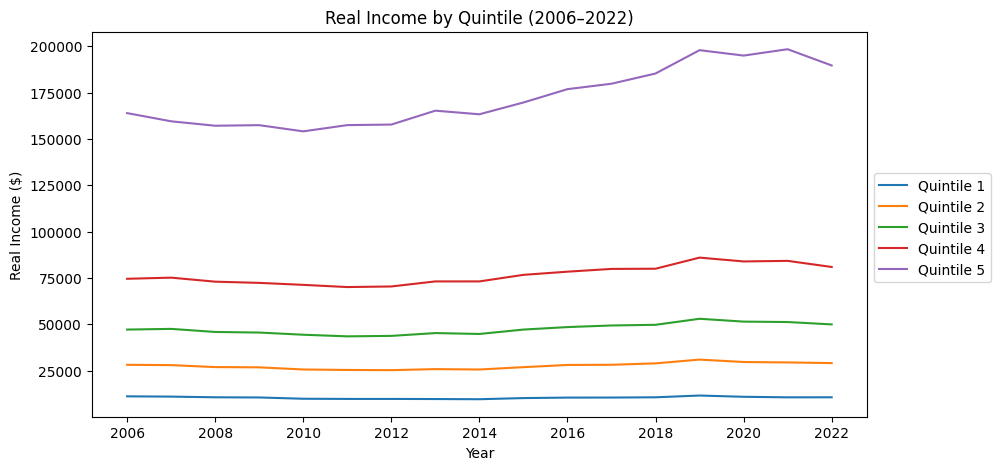

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Plot real income for each quintile over time
for quintile in range(1, 6):
    quintile_data = joined_long[joined_long['Quintile'] == quintile]
    plt.plot(
        quintile_data['Year'],
        quintile_data['Real Income'],
        label=f'Quintile {quintile}'
    )

plt.xlabel('Year')
plt.ylabel('Real Income ($)')
plt.title('Real Income by Quintile (2006–2022)')
plt.legend(bbox_to_anchor=(1, 0.65))
plt.show()

### Real Income Over Time by Quintile

This line chart displays real income for each of the five quintiles from 2006 to 2022. Real income is calculated by dividing nominal income by CPI and multiplying by 100 (as shown above), and this removes the effect of inflation. By doing this we are able to compare the actual purchasing power over time. 

We can observe several patterns from this data. The highest earners (Quintile 5) consistently holds the largest real income. Meanwhile, the lowest earners (quintile 1) is near the bottom for the entire time period. We can also observe that real incomes decline around 2020-2022 which reflects the effects of COVID-19 income related disruptions followed by a surge in inflation after the pandemic. The lowest quintile shows the least recovery which can lead us to assume that low-income houseolds had the hardest time keeping up with rising prices during periods of high inflation. 

In [8]:
# Find the percent change every year for each quintile (2006 is excluded since it has no previous year to compare to)
joined_long['Real Income Growth'] = joined_long.groupby('Quintile')['Real Income'].pct_change() * 100
joined_long.head()

,Year,Quintile,CPI,Income,Real Income,Real Income Growth
0,2006,1,102.345000,11350,11089.940886,NaN
1,2007,1,105.619917,11550,10935.437524,-1.393185
2,2008,1,110.252333,11660,10575.739894,-3.289284
3,2009,1,110.224750,11550,10478.590335,-0.918608
4,2010,1,112.250917,10990,9790.565927,-6.566002


### Computing Real Income Growth

We calculated the percent change in real income for each of the five quintiles in order to understand how purchasing power and how it changes from year to year. The last column measures the percent change in inflation-adjusted incomes within each quintile group. When the values are positive, this means that the real purchasing power grew. While negative values mean that purchasing power decreased. This is essential in comparing how well each income group keeps up with inflation over time. 

In [9]:
# Take the average percent change every year for each quintile and display it in a table
avg_growth = joined_long.groupby('Quintile')['Real Income Growth'].mean().rename('Average Growth (%)')
pandas.DataFrame(avg_growth)

,Average Growth (%)
Quintile,
1,-0.225693
2,0.251144
3,0.400327
4,0.555602
5,0.959302


### Average Real Income Growth 

This table presents the average annual real income growth rate for each of the five quintiles from 2006-2022. The results show that Quintile 1 (low earners) had a negative growth rate of -0.23% which means that their inflation-adjusted income declined every year. On the other hand, Quintile 5 (highest earners) had a positive growth rate of 0.96%. 

The data showing that the average real income growth increases consistently from lowest to highest quintile supports our first research question looking at whether lower-income groups are hit harder by inflation than high-income ones. 


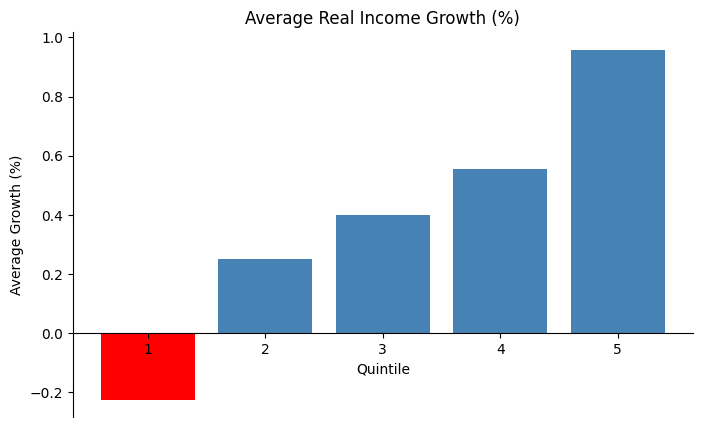

In [10]:
fig, ax = plt.subplots(figsize=(8,5))

colors = ['red' if x < 0 else 'steelblue' for x in avg_growth]
ax.bar(avg_growth.index, avg_growth, color=colors)

ax.spines['bottom'].set_position('zero')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.xlabel('Quintile')
plt.ylabel('Average Growth (%)')
plt.title('Average Real Income Growth (%)')
plt.show()

This bar chart visualizes the differences in average real income growth between 5 quintiles. Negative average growth percents are red to represent a decrease in purchasing power while positive average growth percents are blue to represent an increase in purchasing power. Here we see that the only quintile that is red is the first quintile, which are groups in the bottom 20% of average household income. We also see that the jump from the fourth quintile to the fifth quintile is the biggest, showing how groups in the top 20% of average household income gained the most purchasing power.

### Procedural Changes & Iteration Reflection

Since Part 1, our project evolved in a few important ways. First, we refined our focus to be more data driven and specific to measurable economic indicators. Initially, our topic broadly explored \"who is affected by inflation,\" but we narrowed this down to analyzing income quintiles using CPI data and comparing it with wage/income trends over time.

### Conclusion

In this project, we analyzed how inflation impacts different income groups by comparing CPI trends across income quintiles and aligning them with mean household income data from 2005 to 2022. Our findings show that although inflation increases at similar rates across all quintiles, lower income groups are more heavily affected because they have less income to absorb rising costs. This results in a greater loss of purchasing power for lower income households.

By reshaping and combining datasets, we were able to more effectively compare trends across income levels and better understand the relationship between inflation and income. Overall, our analysis supports the idea that inflation disproportionately impacts lower income groups. In the future, this project could be expanded by including regional data or industry specific wage trends to gain deeper insights into how inflation affects different populations.

Specifically, for part 3, we plan on investigating our other two research questions: "Do wages keep up with inflation across different industries?" and "Are certain states hit harder by inflation than others?" With the recent technological advances in AI/ML, we want to find out whether certain industries have been hit harder than others and if there are any significant inflation disparities between states.

### Credit Listing

- Sanjana Devakumaran *(sanjud)*: Researched relevant datasets and annotated/documented the code for clarity and readability.
- Sanjna Rachakonda *(sanjnarachakonda)*: Led the analysis from Part 1 to Part 2, documented key findings, and contributed to additional data research.
- Tommy Ayers *(tlayers21)*: Identified and analyzed trends across income quintiles, joined data together, calculated real income and real income growth, and visualized real income across the different quintiles.
- Johnson Hwang *(hjohnson22)*: Found the CPI and Income datasets, cleaned data, and revised the notebook based on our part 1 submission feedback.

# Part 3

 - https://apps.bea.gov/itable/?ReqID=70&step=1&_gl=1*1dkdgnd*_ga*MTc4NDYyNDg2NS4xNzc0NTQzNzUx*_ga_J4698JNNFT*czE3NzczMzMwMTMkbzIkZzAkdDE3NzczMzMwMTMkajYwJGwwJGgw#eyJhcHBpZCI6NzAsInN0ZXBzIjpbMSwyOSwyNSwzMSwyNiwyNywzMCwzMF0sImRhdGEiOltbIlRhYmxlSWQiLCIzNiJdLFsiTWFqb3JfQXJlYSIsIjAiXSxbIlN0YXRlIixbIjAiXV0sWyJBcmVhIixbIlhYIl1dLFsiU3RhdGlzdGljIiwiMSJdLFsiVW5pdF9vZl9tZWFzdXJlIiwiTGV2ZWxzIl0sWyJZZWFyIixbIi0xIl1dLFsiWWVhckJlZ2luIiwiLTEiXSxbIlllYXJfRW5kIiwiLTEiXV19

 - https://sites.google.com/view/jadhazell/state-consumer-price-index

In [24]:
state_income = pandas.read_csv("data/state_income.csv", skiprows=3)
state_income = state_income.iloc[:60, :]
state_income

,GeoFIPS,GeoName,1948:Q1,1948:Q2,1948:Q3,1948:Q4,1949:Q1,1949:Q2,1949:Q3,1949:Q4,...,2023:Q3,2023:Q4,2024:Q1,2024:Q2,2024:Q3,2024:Q4,2025:Q1,2025:Q2,2025:Q3,2025:Q4
0,00000,United States,204641.7,210069.4,215368.6,215900.3,209582.6,208642.9,208379.3,209431.3,...,23724337.7,24020535.7,24466466.2,24790949.1,25014714.4,25318322.2,25713267.6,25982179.3,26263006.0,26480869.9
1,01000,Alabama,2496.0,2595.6,2669.2,2707.1,2561.9,2516.7,2473.5,2501.7,...,280991.1,285011.4,289618.5,294230.3,297585.6,300927.5,306492.5,309858.4,310778.7,312496.1
2,02000,Alaska *,(NA),(NA),(NA),(NA),(NA),(NA),(NA),(NA),...,53918.5,54513.7,55420.6,56122.7,56762.7,57386.6,58274.4,58950.6,59271.0,59945.8
3,04000,Arizona,896.6,919.4,968.7,953.5,937.9,964.4,957.9,974.8,...,474428.2,477882.6,490807.9,496509.5,500219.5,508077.4,511732.5,518739.1,523131.2,528693.5
4,05000,Arkansas,1452.2,1645.4,1670.4,1661.8,1604.2,1490.6,1477.1,1463.4,...,173772.8,175251.6,179391.2,181404.5,184746.6,187265.0,191692.8,192049.8,192642.7,192997.3
5,06000,California,17748.1,18093.5,18537.0,18719.4,18449.5,18480.3,18614.8,18862.2,...,3204010.8,3238999.7,3327947.4,3375748.5,3415182.6,3482070.6,3533519.2,3537859.4,3623000.6,3649184.2
6,08000,Colorado,1822.8,1861.0,1913.3,1925.4,1894.4,1915.9,1919.2,1928.8,...,475241.9,481700.5,486154.3,493454.3,496925.6,502660.3,511131.8,516140.3,520814.0,524585.3
7,09000,Connecticut,3417.8,3459.5,3561.6,3596.6,3423.7,3400.4,3410.5,3434.8,...,330487.4,334897.1,343986.5,347817.2,351013.1,354691.4,359919.9,363435.2,366037.7,369471.3
8,10000,Delaware,507.7,514.3,532.4,541.3,569.4,567.1,570.1,573.5,...,67236.5,67952.7,69986.2,71230.9,72111.1,73048.7,74717.0,75474.0,75990.0,76359.8
9,11000,District of Columbia,1744.1,1764.0,1795.4,1819.0,1811.8,1835.3,1853.4,1878.6,...,73706.1,74491.3,76777.4,77766.2,78256.9,79517.5,79969.8,80609.5,80703.3,80903.7


In [21]:
state_cpi = pandas.read_csv("data/state_inflation.csv")
state_cpi

,state,year,quarter,pi_nt,pi_t,pi
0,Alabama,1989,1,3.605220,4.337426,3.984353
1,Alabama,1989,2,3.785178,5.133499,4.427839
2,Alabama,1989,3,4.118384,4.125880,4.173073
3,Alabama,1989,4,3.418778,3.440917,3.485882
4,Alabama,1990,1,2.821664,5.082320,3.865541
...,...,...,...,...,...,...
4694,Wisconsin,2016,4,0.918096,-1.442765,0.168776
4695,Wisconsin,2017,1,2.218032,0.329994,1.740557
4696,Wisconsin,2017,2,2.601992,0.969112,2.246920
4697,Wisconsin,2017,3,2.638051,1.608704,2.432090
